# 調査結果によるスコア化

## 【健康な人の特徴】

しっかり寝ている（7〜8時間）

BMI値が19以下

運動時間40時間以上

ストレスレベル"low"

睡眠の質"good"

身体活動レベル"active"



## 【不健康な人の特徴】



睡眠時間が短い（5〜6時間）

BMI値が27以上

消費カロリーが1400以下

歩数が5000以下

運動時間30時間以下

ストレスレベル"High"

睡眠の質"poor "

身体活動レベル"sedentary"又は"moderate"

喫煙・飲酒"yes"

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
from my_plot import Hist, sns_Hist, sns_kde

In [47]:


def add_health_scores(df):

    # 健康スコア（当てはまる条件の合計）
    df['healthy_score'] = (
        df['sleep_duration'].between(7, 8).astype(int) +
        (df['bmi'] <= 19).astype(int) +
        (df['exercise_duration'] >= 40).astype(int) +
        (df['stress_level'] == 'low').astype(int) +
        (df['sleep_quality'] == 'good').astype(int) +
        (df['physical_activity_level'] == 'active').astype(int)
    )

    # 不健康スコア（当てはまる条件の合計）
    # ※ 'poor ' のようなデータ末尾の空白混入エラーを防ぐため .str.strip() を使用
    df['unhealthy_score'] = (
        df['sleep_duration'].between(5, 6).astype(int) +
        (df['bmi'] >= 27).astype(int) +
        (df['calorie_expenditure'] <= 1400).astype(int) +
        (df['step_count'] <= 5000).astype(int) +
        (df['exercise_duration'] <= 30).astype(int) +
        (df['stress_level'] == 'High').astype(int) +
        (df['sleep_quality'].astype(str).str.strip() == 'poor').astype(int) +
        df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
        (df['smoking_alcohol'] == 'yes').astype(int)
    )

    return df

In [48]:
df = add_health_scores(pd.read_csv("train.csv"))

In [49]:
df["healthy_score"].value_counts()

,count
healthy_score,
1,206168
2,201906
0,126074
3,110349
4,37157
5,7681
6,753


In [50]:
df["unhealthy_score"].value_counts()

,count
unhealthy_score,
2,188892
1,171187
3,140494
0,99608
4,66426
5,19701
6,3519
7,259
8,2


# 健康スコア

健康スコア


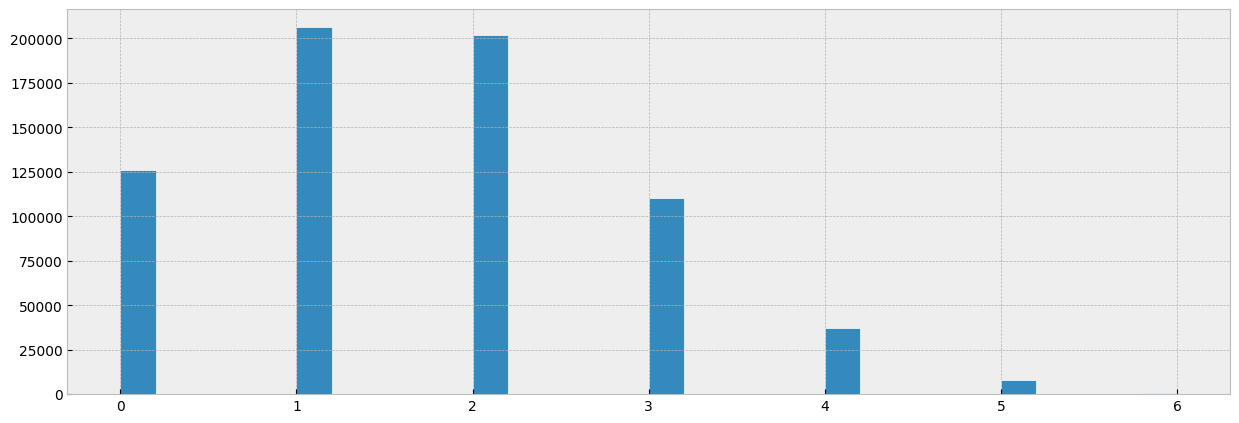

In [59]:
print("健康スコア")
Hist(data=df,column_name="healthy_score",figsize=(15, 5),step=1)

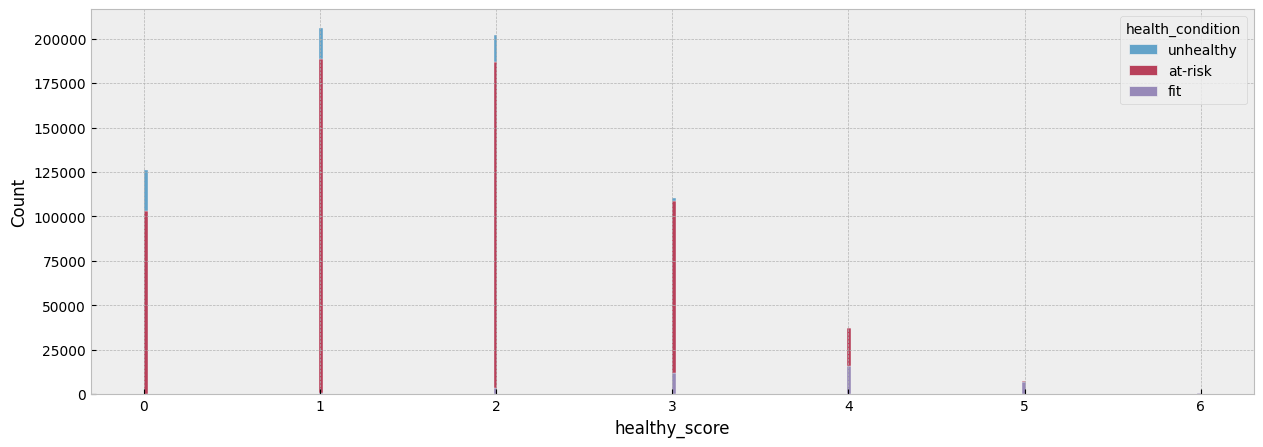

In [53]:
sns_Hist(data=df,x="healthy_score",hue='health_condition',figsize=(15,5),step=1)

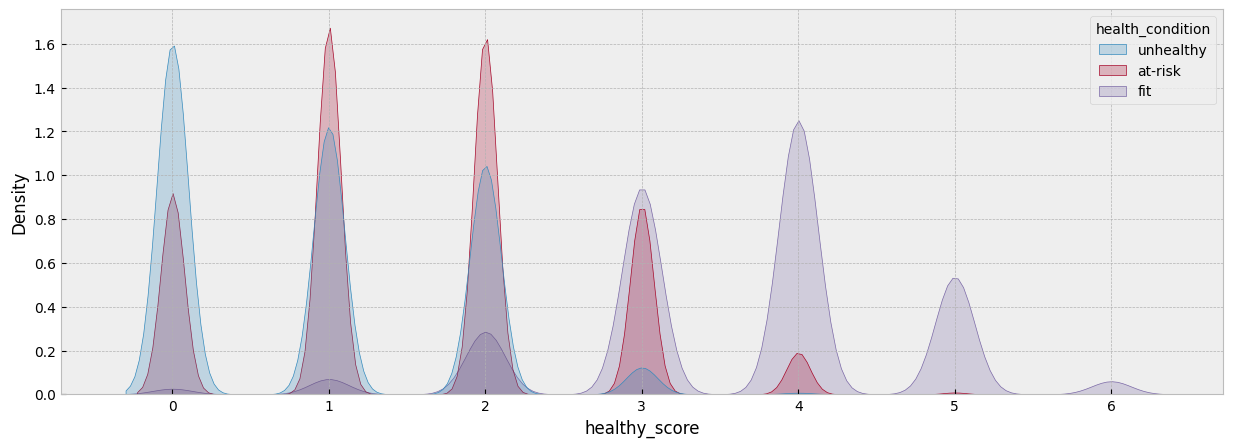

In [57]:
sns_kde(data=df,x="healthy_score",hue='health_condition',figsize=(15, 5),step=1)

# 不健康スコア

不健康スコア


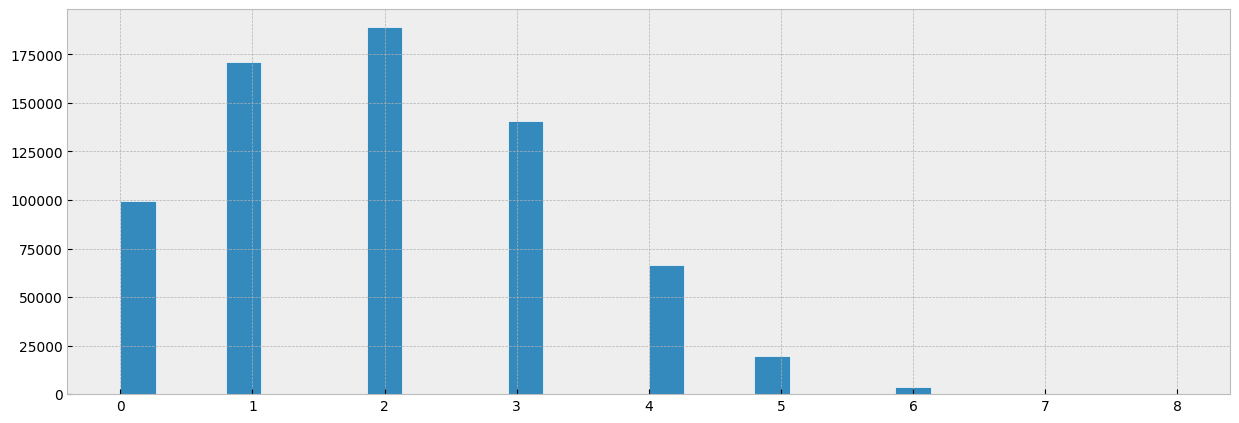

In [60]:
print("不健康スコア")
Hist(data=df,column_name="unhealthy_score",figsize=(15, 5),step=1)

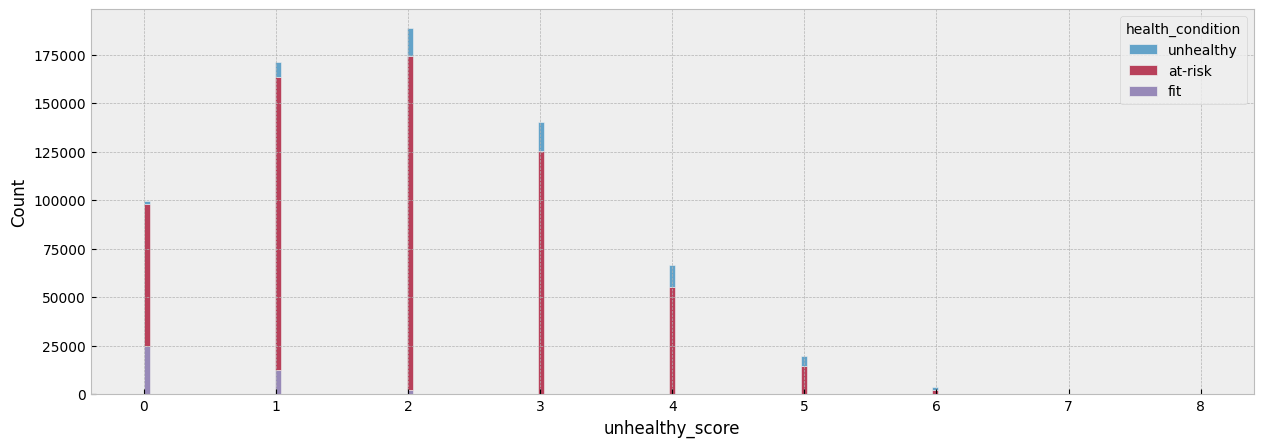

In [61]:
sns_Hist(data=df,x="unhealthy_score",hue='health_condition',figsize=(15,5),step=1)

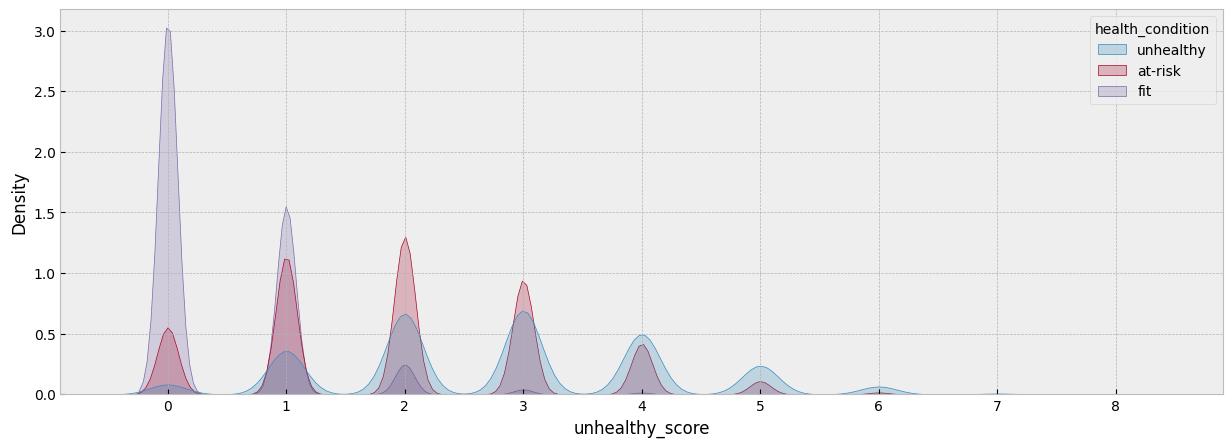

In [62]:
sns_kde(data=df,x="unhealthy_score",hue='health_condition',figsize=(15, 5),step=1)